42
56
60
61
88
64
26
35
71
71
54
40
48
61
50
69
52
70
48
61
29
45
46
30
38
46
47
52
29
53
21
27
51
24
31
26
21
32
26
42
19
35
29
32
30
45
22
20
16
16
29
32
20
25
45
20
36
30
33
16
27
39
31
38
39
15
14
13
18
23
12
14
34
19
19
35
34
22
18
24
16
16
13
18
19
18
24
29
20
10
23
8
12
28
22
16
22
15
29
11
25
23
25
26
12
24
9
22
14
13
23
17
25
29
9
9
23
15
14
26
21
8
22
19
17
21
23
25
22
10
9
17
11
13
15
9
18
8
16
16
6
22
21
22
15
9
12
22
21
8
17
13
20
20
13
18
8
9
11
20
13
14
14
6
20
6
8
7
16
7
18
17
10
7
12
11
17
7
14
13
19
7
6
18
16
14
8
15
7
14
6
6
14
14
16
17
15
11
4
4


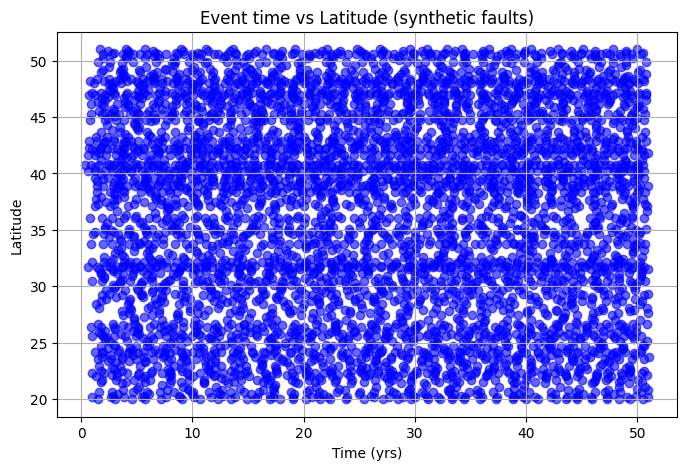

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from CS224W_Project.data.inverse_gaussian import rbht  # your BPT random draw
import random

def simulate_fault_events_geo(R, v_loading_rate,
                              delta_sigma_const, gamma,
                              time_horizon,
                              mu_shear_modulus = 3e10,
                              fault_lat = 0.0, fault_lon = 0.0, fault_depth = 10.0):
    """
    Simulate earthquake events for a fault patch with:
      - radius R
      - constant loading + BPT variability
      - geographic embedding: latitude, longitude, depth (constant)
    """
    c = 7/16
    μ = mu_shear_modulus
    
    # slip per event from scaling
    u = (delta_sigma_const * R) / (c * μ * np.pi)
    mu_rec = u / v_loading_rate
    
    # Generate inter-event times via BPT
    n_draw = int(np.ceil(time_horizon / mu_rec * 2))
    inter_times = rbht(n_draw, mu_rec, gamma)
    event_times = np.cumsum(inter_times)
    event_times = event_times[event_times <= time_horizon]
    
    # Magnitude
    Mo = μ * np.pi * (R**2) * u
    Mw = (2/3)*np.log10(Mo) - 6.03
    
    # Recurrence intervals
    rec_int = np.concatenate([[np.nan], np.diff(event_times)])
    
    # For each event, record lat/lon/depth as constant
    latitudes = np.full_like(event_times, fault_lat, dtype = float)
    longitudes = np.full_like(event_times, fault_lon, dtype = float)
    depths = np.full_like(event_times, fault_depth, dtype = float)
    l = np.full_like(event_times, v_loading_rate, dtype = float)
    print(len(event_times))
    df = pd.DataFrame({
        'fault_radius': R,
        'event_time': event_times,
        'magnitude': Mw,
        'rec_interval': rec_int,
        'latitude': latitudes,
        'longitude': longitudes,
        'depth': depths,
        "loading_rate": v_loading_rate
    })
    return df

# --- Simulate many faults with varying latitude ---
fault_radii = np.linspace(80, 400, num = 200)
v_loading_rate = 0.01
delta_sigma_const = 4e6
gamma = 0.25
time_horizon = 51

# Let’s assign each fault a latitude spaced linearly, same lon & depth
base_lon = -122.0    # some constant longitude (e.g. in California)
base_depth = 12.0    # km (just chosen)
min_lat, max_lat = 20.0, 51.0

catalog_list = []
lats = np.linspace(min_lat, max_lat, 200)
lats = random.sample(list(lats), len(fault_radii))
loading_rates = np.random.uniform(0.004, 0.014, len(fault_radii))
for R, lat, v in zip(fault_radii, lats, loading_rates):
    df = simulate_fault_events_geo(R,
                                   v, 
                                   delta_sigma_const,
                                   gamma,
                                   time_horizon,
                                   mu_shear_modulus = 3e10,
                                   fault_lat = lat,
                                   fault_lon = base_lon,
                                   fault_depth = base_depth)
    catalog_list.append(df)

catalog = pd.concat(catalog_list, ignore_index = True)

# --- Visualize: Event time vs latitude (instead of vs fault size) ---
plt.figure(figsize = (8,5))
plt.scatter(catalog['event_time'], catalog['latitude'], c = 'blue', alpha = 0.6)
plt.xlabel('Time (yrs)')
plt.ylabel('Latitude')
plt.title('Event time vs Latitude (synthetic faults)')
plt.grid(True)
plt.show()

# Also you can still do magnitude vs latitude, or map them on geographic map if desired.

In [5]:
catalog.to_excel("synthetic_data.xlsx", index = False)